**Date Exploration**

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline
import seaborn as sns

In [2]:
df = pd.read_csv("Walmart.csv")

In [3]:
df.shape

(10051, 11)

In [4]:
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48


In [5]:
df.describe(include="all")

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
count,10051.000000,10051,10051,10051,10020,10020.000000,10051,10051,10051,10051.000000,10051.000000
unique,NaN,100,98,6,1008,NaN,1460,1001,3,NaN,NaN
top,NaN,WALM058,Weslaco,Fashion accessories,$63,NaN,01/12/21,15:48:00,Credit card,NaN,NaN
freq,NaN,240,399,4579,159,NaN,48,33,4260,NaN,NaN
mean,5025.741220,NaN,NaN,NaN,NaN,2.353493,NaN,NaN,NaN,5.825659,0.393791
std,2901.174372,NaN,NaN,NaN,NaN,1.602658,NaN,NaN,NaN,1.763991,0.090669
min,1.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,3.000000,0.180000
25%,2513.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,4.000000,0.330000
50%,5026.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,6.000000,0.330000
75%,7538.500000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,7.000000,0.480000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  object 
 2   City            10051 non-null  object 
 3   category        10051 non-null  object 
 4   unit_price      10020 non-null  object 
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  object 
 7   time            10051 non-null  object 
 8   payment_method  10051 non-null  object 
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 863.9+ KB


In [7]:
df.duplicated().sum()

np.int64(51)

In [8]:
df.isnull().sum()

invoice_id         0
Branch             0
City               0
category           0
unit_price        31
quantity          31
date               0
time               0
payment_method     0
rating             0
profit_margin      0
dtype: int64

**Data Cleaning**

In [9]:
# drop duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [10]:
# check for nulls
df[df["quantity"].isnull()][["quantity", "unit_price"]]

,quantity,unit_price
1892,NaN,NaN
1893,NaN,NaN
1894,NaN,NaN
1895,NaN,NaN
1896,NaN,NaN
1897,NaN,NaN
1898,NaN,NaN
1899,NaN,NaN
1900,NaN,NaN
1901,NaN,NaN


In [11]:
# drop nulls
df.dropna(inplace=True)
df.isnull().sum()

invoice_id        0
Branch            0
City              0
category          0
unit_price        0
quantity          0
date              0
time              0
payment_method    0
rating            0
profit_margin     0
dtype: int64

In [12]:
# handle "unit_price" column data type
df["unit_price"] = df["unit_price"].str.replace("$", "").astype(float)
df["unit_price"].head()

0    74.69
1    15.28
2    46.33
3    58.22
4    86.31
Name: unit_price, dtype: float64

In [13]:
# add "total_price" column
df["total_price"] = df["unit_price"] * df["quantity"]
df["total_price"].head()

0    522.83
1     76.40
2    324.31
3    465.76
4    604.17
Name: total_price, dtype: float64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9969 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      9969 non-null   int64  
 1   Branch          9969 non-null   object 
 2   City            9969 non-null   object 
 3   category        9969 non-null   object 
 4   unit_price      9969 non-null   float64
 5   quantity        9969 non-null   float64
 6   date            9969 non-null   object 
 7   time            9969 non-null   object 
 8   payment_method  9969 non-null   object 
 9   rating          9969 non-null   float64
 10  profit_margin   9969 non-null   float64
 11  total_price     9969 non-null   float64
dtypes: float64(5), int64(1), object(6)
memory usage: 1012.5+ KB


In [15]:
df.columns = df.columns.str.lower()

In [16]:
# change "date" data type
df["date"] = pd.to_datetime(df["date"])

C:\Users\Admin\AppData\Local\Temp\ipykernel_16488\558680609.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [17]:
df["profit"] = df["total_price"] * df["profit_margin"]

In [18]:
# save file
df.to_csv("Walmart_clean_data.csv", index=False)

In [19]:
df.head(10)

,invoice_id,branch,city,category,unit_price,quantity,date,time,payment_method,rating,profit_margin,total_price,profit
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,2019-05-01,13:08:00,Ewallet,9.1,0.48,522.83,250.9584
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,2019-08-03,10:29:00,Cash,9.6,0.48,76.40,36.6720
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,2019-03-03,13:23:00,Credit card,7.4,0.33,324.31,107.0223
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,2019-01-27,20:33:00,Ewallet,8.4,0.33,465.76,153.7008
4,5,WALM013,Irving,Sports and travel,86.31,7.0,2019-08-02,10:37:00,Ewallet,5.3,0.48,604.17,290.0016
5,6,WALM026,Denton,Electronic accessories,85.39,7.0,2019-03-25,18:30:00,Ewallet,4.1,0.48,597.73,286.9104
6,7,WALM088,Cleburne,Electronic accessories,68.84,6.0,2019-02-25,14:36:00,Ewallet,5.8,0.33,413.04,136.3032
7,8,WALM100,Canyon,Home and lifestyle,73.56,10.0,2019-02-24,11:38:00,Ewallet,8.0,0.18,735.60,132.4080
8,9,WALM066,Grapevine,Health and beauty,36.26,2.0,2019-10-01,17:15:00,Credit card,7.2,0.33,72.52,23.9316
9,10,WALM065,Texas City,Food and beverages,54.84,3.0,2019-02-20,13:27:00,Credit card,5.9,0.33,164.52,54.2916


<b><h1>INSIGHTS</h1></b>

# 🛒 Walmart Sales Analysis Dashboard

This report summarizes the key performance indicators (KPIs) and trends derived from the analysis of **9,969** retail transactions.

---

### 💰 Financial Executive Summary
* **Total Revenue:** $1,209,726.38
* **Total Profit:** $476,139.42
* **Average Transaction Value (ATV):** $121.35
* **Peak Shopping Hour:** **15:00 (3 PM)** — Records 1,191 transactions, marking the start of a sustained afternoon surge.
* **Core Drivers of Profitability:**
    * **Quantity vs. Profit (0.7565):** Strongest driver; high-volume sales dictate the bottom line.
    * **Unit Price vs. Profit (0.5007):** Moderate impact; pricing matters but is secondary to volume.
    * **Total Price vs. Profit (0.9487):** Near-perfect correlation, indicating highly consistent profit margins.
* **Customer Insight:** **Total Price vs. Rating (0.1111)** — Customer satisfaction is independent of the transaction size.
---

### 📊 Category Performance: Comprehensive Efficiency Analysis
| Category | Total Revenue | Total Profit | **Aggregate Margin (Cash)** | **Avg. Receipt Margin (Mean)** | **Avg. Rating** |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Food and beverages** | $53,471.28 | $21,552.86 | **40.31%** | 40.03% | **7.11** |
| **Health and beauty** | $46,851.18 | $18,671.73 | **39.85%** | 40.03% | **7.00** |
| **Electronic accessories** | $78,175.03 | $30,772.49 | 39.36% | 39.32% | 5.91 |
| **Fashion accessories** | $489,480.90 | $192,314.89 | 39.29% | 39.29% | 5.78 |
| **Home and lifestyle** | $489,250.06 | $192,213.64 | 39.29% | 39.46% | 5.74 |
| **Sports and travel** | $52,497.93 | $20,613.81 | **39.27%** | 38.22% | 6.92 |

<br>

> **Analyst Note:** > * **Aggregate Margin** reflects the actual cash return ($\sum \text{Profit} / \sum \text{Revenue}$). 
> * **Avg. Receipt Margin** represents the typical performance per transaction. 
> * The high performance of **Food & Beauty** in both margin and rating indicates a strong "Essential Goods" core.

---

### 📅 Seasonality & Trends

#### **Hourly Traffic Analysis (High-Volume Hours > 900)**
| Hour | Transaction Count | Period |
| :--- | :--- | :--- |
| **15:00** | 1,191 | 🏆 Daily Peak |
| **16:00** | 1,173 | Afternoon High |
| **17:00** | 1,027 | Afternoon Surge |
| **19:00** | 1,024 | Evening Rush |
| **18:00** | 986 | Late Afternoon |
| **20:00** | 972 | Evening Peak |

*Note: While the store technically opens at 06:00, foot traffic remains negligible until the 11:00 AM surge, where counts jump from ~311 to ~403 transactions.*

#### **Monthly Revenue Distribution**
| Month | Revenue ($) | Month | Revenue ($) |
| :--- | :--- | :--- | :--- |
| **Jan** | 144,028.54 | **Jul** | 55,140.06 |
| **Feb** | 109,313.66 | **Aug** | 83,173.74 |
| **Mar** | 115,658.00 | **Sep** | 86,269.70 |
| **Apr** | 49,987.69 | **Oct** | 81,188.43 |
| **May** | 57,337.23 | **Nov** | 183,972.35 |
| **Jun** | 58,313.50 | **Dec** | 185,343.48 |

#### **Weekly Revenue Ranking**
| Day of Week | Revenue ($) | Status |
| :--- | :--- | :--- |
| **Tuesday** | $184,200.78 | 🏆 Peak Day |
| **Sunday** | $182,409.71 | High |
| **Saturday** | $176,043.18 | High |
| **Wednesday** | $171,501.58 | Moderate |
| **Thursday** | $170,830.39 | Moderate |
| **Friday** | $169,546.83 | Moderate |
| **Monday** | $155,193.91 | 📉 Lowest |

#### **Daily Revenue "Hot Spots" (Top 7 Days of Month)**
1. **12th:** $103,512.00
2. **11th:** $97,911.00
3. **3rd:** $57,417.13
4. **2nd:** $56,505.75
5. **19th:** $49,074.51
6. **1st:** $47,489.89
7. **15th:** $45,512.01

---

### 📈 Full Statistical Correlation Matrix
| | **unit_price** | **quantity** | **profit** | **total_price** | **rating** |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **unit_price** | 1.0000 | 0.0618 | 0.5007 | 0.5306 | 0.0194 |
| **quantity** | 0.0618 | 1.0000 | 0.7565 | 0.8002 | 0.1367 |
| **profit** | 0.5007 | 0.7565 | 1.0000 | **0.9487** | 0.1198 |
| **total_price**| 0.5306 | 0.8002 | **0.9487** | 1.0000 | 0.1111 |
| **rating** | 0.0194 | 0.1367 | 0.1198 | 0.1111 | 1.0000 |

<br>

> **Analyst Note:** The strong correlation between **Quantity and Profit (0.7565)** underscores a volume-driven business model where sales frequency outweighs individual unit pricing as a driver of growth. Furthermore, a clear category divergence exists: while **Fashion** and **Home** items act as primary revenue engines, **Food & Beverages** maintain the highest customer satisfaction (7.11), suggesting that essential goods are the key drivers of customer loyalty.

In [20]:
# Total Revenue
df["total_price"].sum().round(2)

np.float64(1209726.38)

In [21]:
# Total Profit
df["profit"].sum().round(2)

np.float64(476139.43)

In [22]:
# Average Transaction Value
df["total_price"].mean().round(2)

np.float64(121.35)

In [23]:
# Total Revenue vs Profit by Category
df.groupby("category")[["total_price", "profit"]].sum().sort_values(by="total_price" , ascending=False).round(2)

,total_price,profit
category,,
Fashion accessories,489480.90,192314.89
Home and lifestyle,489250.06,192213.64
Electronic accessories,78175.03,30772.49
Food and beverages,53471.28,21552.86
Sports and travel,52497.93,20613.81
Health and beauty,46851.18,18671.73


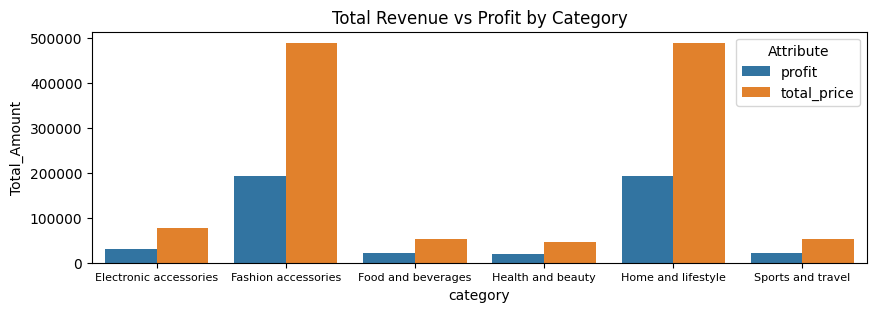

In [24]:
# Visualize Total Revenue vs Profit by Category
df_category = df.groupby("category")[["profit", "total_price"]].sum().reset_index()

df_melted_category = df_category.melt(id_vars="category", var_name="Attribute", value_name="Total_Amount")

plt.figure(figsize=(10, 3))
sns.barplot(data=df_melted_category, x="category", y="Total_Amount", hue="Attribute")
plt.title("Total Revenue vs Profit by Category")
plt.xticks(fontsize=8)
plt.show()

In [25]:
# Add month column
df["month"] = df["date"].dt.month

In [26]:
# Total Revenue vs Profit by Category
df.groupby("month")[["total_price", "profit"]].sum().round(2)

,total_price,profit
month,,
1,144028.54,56778.61
2,109313.66,43440.92
3,115658.00,45385.13
4,49987.69,19510.65
5,57337.23,23017.19
6,58313.50,23205.13
7,55140.06,21922.10
8,83173.74,33721.64
9,86269.70,33932.72


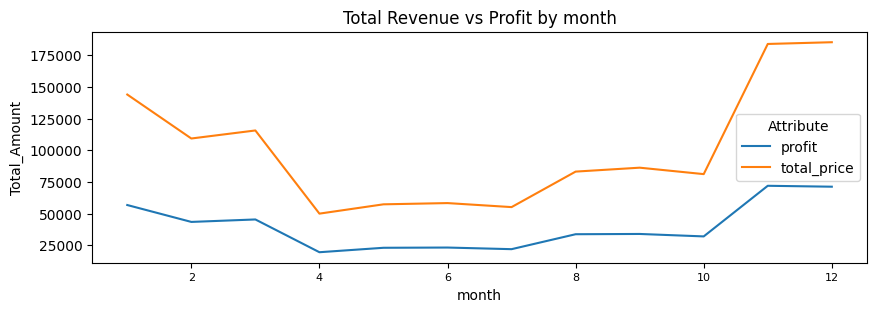

In [27]:
# Visualize Total Revenue vs Profit by Category
df_month = df.groupby("month")[["profit", "total_price"]].sum().reset_index()

df_melted_month = df_month.melt(id_vars="month", var_name="Attribute", value_name="Total_Amount")

plt.figure(figsize=(10, 3))
sns.lineplot(data=df_melted_month, x="month", y="Total_Amount", hue="Attribute")
plt.title("Total Revenue vs Profit by month")
plt.xticks(fontsize=8)
plt.show()

In [28]:
# Add day column
df["day"] = df["date"].dt.day

In [29]:
# Add day of the week column
df["day_of_week"] = df["date"].dt.day_name()

In [30]:
# Total Revenue vs Profit by day for top 7 days
df.groupby("day")[[ "total_price", "profit"]].sum().sort_values(by="total_price", ascending=False).reset_index().head(7)

,day,total_price,profit
0,12,103512.00,40507.6800
1,11,97911.00,37984.5600
2,3,57417.13,22933.9974
3,2,56505.75,22618.2933
4,19,49074.51,19304.5620
5,1,47489.89,18399.5712
6,15,45512.01,18119.6181


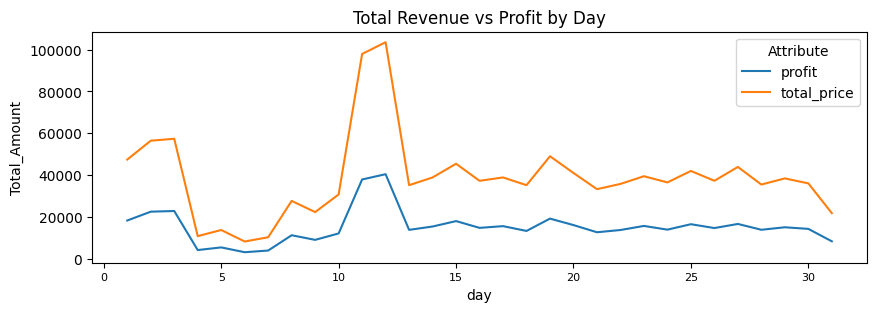

In [31]:
# Visualize Total Revenue vs Profit by day
df_day = df.groupby("day")[["profit", "total_price"]].sum().reset_index()

df_melted_day = df_day.melt(id_vars="day", var_name="Attribute", value_name="Total_Amount")

plt.figure(figsize=(10, 3))
sns.lineplot(data=df_melted_day, x="day", y="Total_Amount", hue="Attribute")
plt.title("Total Revenue vs Profit by Day")
plt.xticks(fontsize=8)
plt.show()

In [32]:
# Total Revenue vs Profit by day of the week
df.groupby("day_of_week")[[ "total_price", "profit"]].sum().sort_values(by="total_price", ascending=False).reset_index()

,day_of_week,total_price,profit
0,Tuesday,184200.78,72398.5524
1,Sunday,182409.71,71314.2078
2,Saturday,176043.18,69957.3966
3,Wednesday,171501.58,66890.9304
4,Thursday,170830.39,67586.3913
5,Friday,169546.83,67436.5050
6,Monday,155193.91,60555.4422


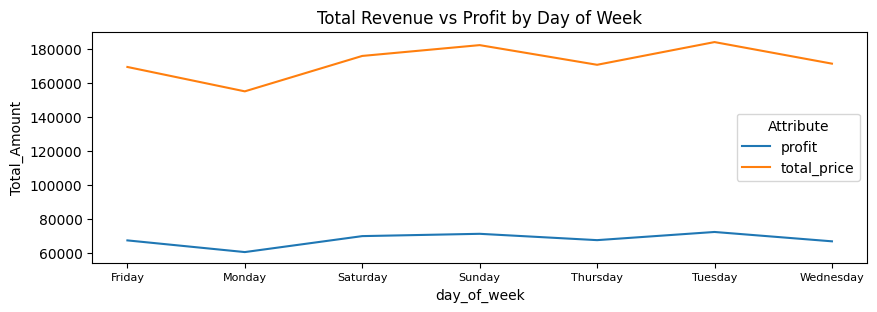

In [33]:
# Visualize Total Revenue vs Profit by day of the week
df_day_of_week = df.groupby("day_of_week")[["profit", "total_price"]].sum().reset_index()

df_melted_day_of_week = df_day_of_week.melt(id_vars="day_of_week", var_name="Attribute", value_name="Total_Amount")

plt.figure(figsize=(10, 3))
sns.lineplot(data=df_melted_day_of_week, x="day_of_week", y="Total_Amount", hue="Attribute")
plt.title("Total Revenue vs Profit by Day of Week")
plt.xticks(fontsize=8)
plt.show()

In [34]:
# Profit Margin Analysis by Category
df.groupby("category")["profit_margin"].mean()

category
Electronic accessories    0.393150
Fashion accessories       0.392915
Food and beverages        0.400345
Health and beauty         0.400263
Home and lifestyle        0.394580
Sports and travel         0.382229
Name: profit_margin, dtype: float64

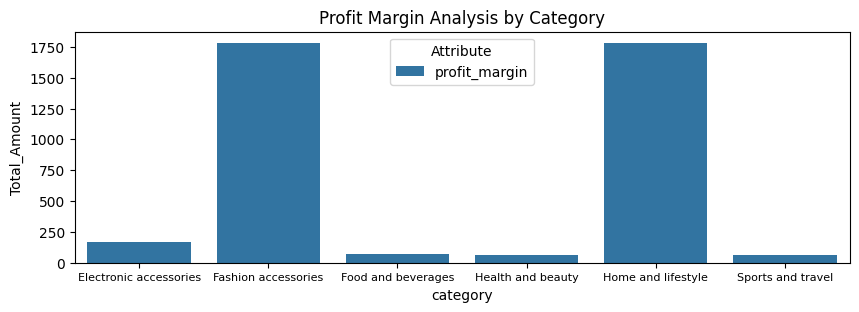

In [35]:
# Visualize Profit Margin Analysis by Category
df_category_profit_margin = df.groupby("category")["profit_margin"].sum().reset_index()

df_melted_category_profit_margin = df_category_profit_margin.melt(id_vars="category", var_name="Attribute", value_name="Total_Amount")

plt.figure(figsize=(10, 3))
sns.barplot(data=df_melted_category_profit_margin, x="category", y="Total_Amount", hue="Attribute")
plt.title("Profit Margin Analysis by Category")
plt.xticks(fontsize=8)
plt.show()

In [36]:
# Correlation (Price vs Quantity vs Profit)
df[["unit_price", "quantity", "profit", "total_price", "rating"]].corr()

,unit_price,quantity,profit,total_price,rating
unit_price,1.000000,0.061789,0.500736,0.530603,0.019407
quantity,0.061789,1.000000,0.756524,0.800156,0.136742
profit,0.500736,0.756524,1.000000,0.948716,0.119827
total_price,0.530603,0.800156,0.948716,1.000000,0.111130
rating,0.019407,0.136742,0.119827,0.111130,1.000000


In [37]:
# Average Rating by Category
df.groupby("category")["rating"].mean()

category
Electronic accessories    5.912172
Fashion accessories       5.782107
Food and beverages        7.113218
Health and beauty         7.003289
Home and lifestyle        5.739159
Sports and travel         6.916265
Name: rating, dtype: float64

In [38]:
# Change "time" data type
df["time"] = pd.to_datetime(df["time"])

C:\Users\Admin\AppData\Local\Temp\ipykernel_16488\3765353473.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"])


In [39]:
# Add "hour" column
df["hour"] = df["time"].dt.hour

In [40]:
# Number of Sales by Hour
df.groupby("hour")[["invoice_id"]].count()

,invoice_id
hour,
6,311
7,338
8,299
9,325
10,411
11,403
12,409
13,436
14,400


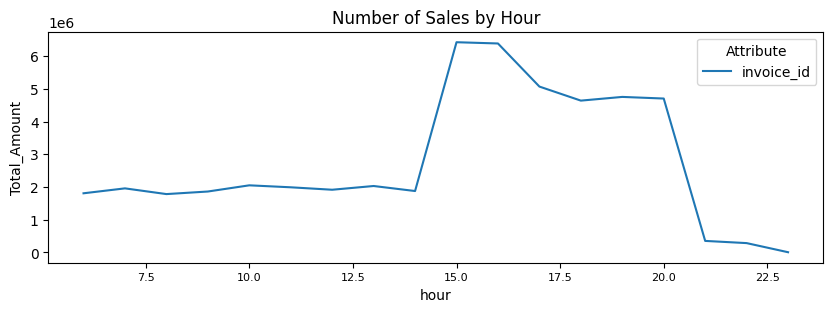

In [41]:
# Visualize Number of Sales by Hour
df_hour = df.groupby("hour")["invoice_id"].sum().reset_index()

df_melted_hour = df_hour.melt(id_vars="hour", var_name="Attribute", value_name="Total_Amount")

plt.figure(figsize=(10, 3))
sns.lineplot(data=df_melted_hour, x="hour", y="Total_Amount", hue="Attribute")
plt.title("Number of Sales by Hour")
plt.xticks(fontsize=8)
plt.show()

In [42]:
# Ratio Between Total Revenue and Profit by Category
grouped = df.groupby("category")[["total_price","profit"]].sum().round(2)
grouped["ratio"] = (grouped["profit"] / grouped["total_price"]).round(4)

grouped

,total_price,profit,ratio
category,,,
Electronic accessories,78175.03,30772.49,0.3936
Fashion accessories,489480.90,192314.89,0.3929
Food and beverages,53471.28,21552.86,0.4031
Health and beauty,46851.18,18671.73,0.3985
Home and lifestyle,489250.06,192213.64,0.3929
Sports and travel,52497.93,20613.81,0.3927


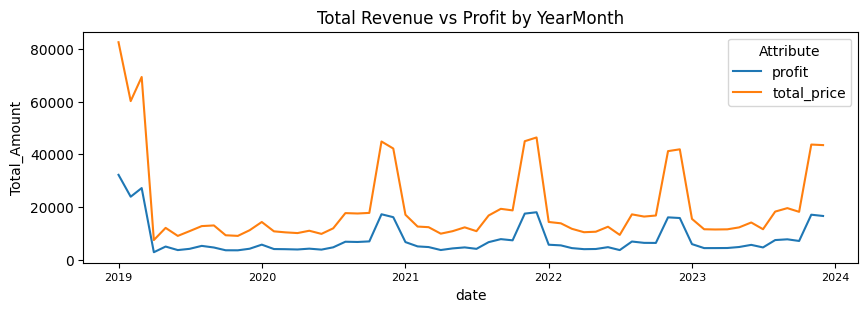

In [43]:
# Visualize Total Revenue and Profit by YearMonth
df_visualize = df.groupby(df["date"].dt.to_period('M'))[["profit", "total_price"]].sum().reset_index()
df_visualize["date"] = df_visualize["date"].dt.to_timestamp()

df_melted_month = df_visualize.melt(id_vars="date", var_name="Attribute", value_name="Total_Amount")

plt.figure(figsize=(10, 3))
sns.lineplot(data=df_melted_month, x="date", y="Total_Amount", hue="Attribute")
plt.title("Total Revenue vs Profit by YearMonth")
plt.xticks(fontsize=8)
plt.show()